# U.S. GDP Growth Rate Analysis Using Curve Fitting & Interpolation

## Introduction

This project looks at U.S. quarterly GDP growth rates from 2010 to 2023 using three different curve fitting and interpolation methods. The data comes from the U.S. Bureau of Economic Analysis (BEA) and shows the seasonally adjusted annual rate (SAAR) of real GDP growth in percent. We are using 20 selected quarters from the full dataset that cover both normal economic periods and the COVID-19 pandemic in 2020, which resulted in some extreme values. The three methods we implement are least squares linear regression, polynomial fitting using the normal equations, and cubic spline interpolation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

x = np.array([0, 4, 8, 12, 16, 18, 21, 24, 26, 27, 28, 32, 36, 40, 41, 42, 44, 48, 53, 54], dtype=float)

print(f"Number of data points: {len(x)}")

Number of data points: 20


---
## Part A — Cubic Spline Interpolation

### A1. Spline Setup

A cubic spline is a way to connect data points using small cubic polynomials instead of one big polynomial over the whole dataset. For each section of points it includes this equation:

$$S_i(x) = a_i + b_i(x - x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3$$

Each piece has 4 unknowns (a, b, c, d), so the total number of unknowns is 4(n-1). For our 20 data points that is 4 * 19 = 76 unknowns. This is alot to solve, so instead of solving directly we focus on the 2nd derivative at each point. This gives us tridiagonal system of size (n-2), which much easier to solve. 

To make the spline smooth, we need to make sure the spline passes through all data points, the 1st derivative is continuous (no sharp corners), the 2nd derivative is continuous (smooth curves), and the 2nd derivative at the end points is 0. 

That gives us 2(n-1) + 2(n-2) = 4n-6 equations, but we need 4n-4. So we are still 2 short. The **natural boundary conditions** fill in the last two by setting the second derivative equal to zero at both endpoints:

$$S''(x_0) = 0 \quad \text{and} \quad S''(x_{n-1}) = 0$$

This basically says the spline is not bending at the ends, which is a reasonable assumption when you do not have extra information about the slope.

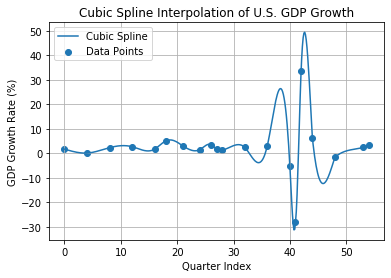

In [2]:
#Set up the tridiagonal system: sets up tridiagonal matrix components needed to solve for 2nd derivative (M)
# at each knot
def setup_tridiagonal(x, y):
    n = len(x)
    h = np.diff(x)
    
    #Intializes diagonals
    A = np.zeros(n-2)
    B = np.zeros(n-2)
    C = np.zeros(n-2)
    D = np.zeros(n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2 * (h[i-1] + h[i])
        C[i-1] = h[i]
        
        #Calculates curvature based on slope of adjacent segment
        D[i-1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

    return A, B, C, D

#Thomas algorithm setup
def thomas(a, b, c, d):
    n = len(b)

    #Forward elimination phase: eliminate the lower diagonal 'a'
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]
    
    # Back sub: solve for unknowns
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1]) / b[i]

    return x

#Solve for second derivatives, assume natural spline boundary conditions where M[0] = M[last] = 0
A, B, C, D = setup_tridiagonal(x, y)
M_internal = thomas(A.copy(), B.copy(), C.copy(), D.copy())


M = np.zeros(len(x))
M[1:-1] = M_internal

#Interpolates a specific point x_eval using the cubic spline formula
def eval_spline(x, y, M, x_eval):
    for i in range(len(x)-1):
        #Check which interval x_eval falls into
        if x[i] <= x_eval <= x[i+1]:
            h = x[i+1] - x[i]
            
            #Relative weights for current interval
            a = (x[i+1] - x_eval) / h
            b = (x_eval - x[i]) / h
            
            #Cubic Spline formula
            return (a*y[i] + b*y[i+1] +
                    ((a**3 - a)*M[i] + (b**3 - b)*M[i+1])*(h**2)/6)

#Plot spline
x_smooth = np.linspace(0, 54, 400)
y_smooth = np.array([eval_spline(x, y, M, xi) for xi in x_smooth])

plt.figure()
plt.scatter(x, y, label="Data Points")
plt.plot(x_smooth, y_smooth, label="Cubic Spline")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Cubic Spline Interpolation of U.S. GDP Growth")
plt.legend()
plt.grid()

plt.show() 

### A2. Evaluating the Spline Over All 55 Quarters

The full dataset from 2010 Q1 to 2023 Q4 has 55 quarters total. We need to place our 20 data points at their correct positions within that range and then evaluate the spline at every quarter index from 1 to 55.

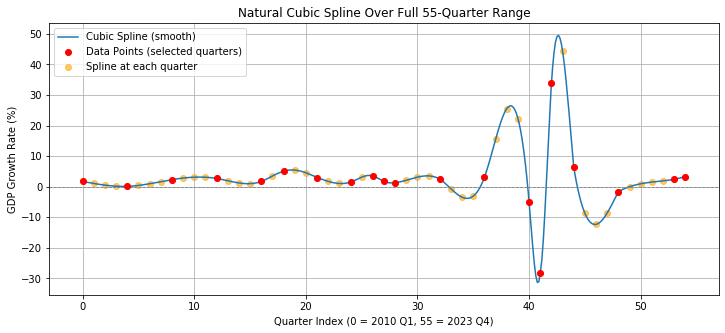

In [3]:

# Smooth spline curve
x_smooth = np.linspace(0, 54, 400)
y_smooth = np.array([eval_spline(x, y, M, xi) for xi in x_smooth])

# Spline evaluated at each quarter
x_55 = np.arange(0, 55)
y_55 = np.array([eval_spline(x, y, M, xi) for xi in x_55])

# Plotting
plt.figure(figsize=(12, 5))

# Original data points
plt.scatter(x, y, color='red', zorder=5, label='Data Points (selected quarters)')

# Smooth cubic spline
plt.plot(x_smooth, y_smooth, label='Cubic Spline (smooth)')

# Spline values at each quarter
plt.scatter(x_55, y_55, color='orange', alpha=0.6, label='Spline at each quarter')

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel("Quarter Index (0 = 2010 Q1, 55 = 2023 Q4)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Natural Cubic Spline Over Full 55-Quarter Range")
plt.legend()
plt.grid()
plt.show()

**Discussion (A2):**

After constructing the spline using the given subset of data points, it was evaluated across all 55 quarters (from 2010 Q1 to 2023 Q4). The resulting plot shows a smooth curve that connects all the given data points. In general, the spline is very smooth and follows the trend of the data. However, in regions where there are extreme values (such as during COVID-19), the curve bends sharply. This is expected because the spline is forced to pass exactly through every point. Overall, the interpolant is visually smooth and reasonable within the range of the data, but it becomes less stable near extreme changes.

### A3. Runge Phenomenon and the COVID Outlier Problem

The Runge phenomenon refers to large oscillations that occur when using high-degree polynomials to interpolate data. Cubic splines help avoid this issue by using smaller, piecewise polynomials instead of one large polynomial. Even though splines are more stable than high-degree polynomials, they still have limitations. In this dataset, the spline must pass exactly through the −28.1% value in 2020 Q2, which is a very large outlier. Because of this, the spline bends sharply in that region. This shows a trade-off:Interpolation methods (like splines) give an exact fit but they can become sensitive to extreme values
In cases like this, smoothing splines or weighted least squares would likely be better choices. These methods do not force the curve to pass exactly through every point, which helps reduce the impact of outliers and results in a more stable overall fit.

---
## Part B — Polynomial & Least Squares Comparison

### B1. Degree-4 Polynomial Fit

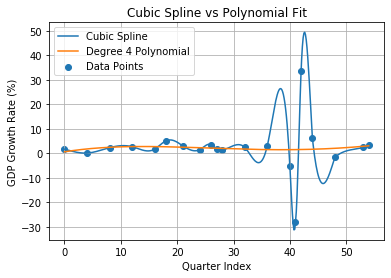

In [4]:
#Vandermonde matrix
#Maps the input x values to their powers based on degree 4 polynomial
def vandermonde(x, degree):
    V = np.zeros((len(x), degree+1))
    for i in range(len(x)):
        for j in range(degree+1):
            V[i,j] = x[i]**j
    return V

degree = 4
V = vandermonde(x, degree)

#Normal equation
#Finds coefficients that minimize the sum of squared residuals
coeffs = np.linalg.solve(V.T @ V, V.T @ y)


#A helper function to calculate the y-value of the polynomial: y = c0 + c1*x + c2*x^2 + ...
def poly(x_val, coeffs):
    return sum(coeffs[i]*x_val**i for i in range(len(coeffs)))

#Generate the y-values for the regression curve over the smooth x-range
y_poly = np.array([poly(xi, coeffs) for xi in x_smooth])


#Plotting
plt.figure()
plt.scatter(x, y, label="Data Points")
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.plot(x_smooth, y_poly, label="Degree 4 Polynomial")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Cubic Spline vs Polynomial Fit")
plt.legend()
plt.grid()

plt.show()

Spline RMSE: 0.0
Polynomial RMSE: 10.03163340585343


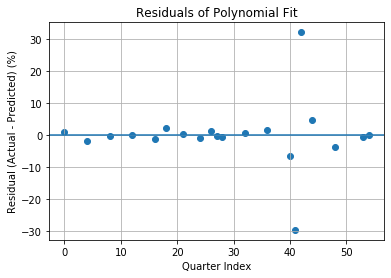

In [5]:
#Root Mean Square Error (RMSE) measures the average magnitude of the error. A lower RMSE indicates a better 
#fit to the data points.
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

#Calculate the predicted GDP growth rates for every original quarter index using both the degree-4 polynomial 
#and the cubic spline.
y_poly_data = np.array([poly(xi, coeffs) for xi in x])
y_spline_data = np.array([eval_spline(x, y, M, xi) for xi in x])

print("Spline RMSE:", rmse(y, y_spline_data))
print("Polynomial RMSE:", rmse(y, y_poly_data))

#Residual plot
residuals = y - y_poly_data
plt.figure()
plt.scatter(x, residuals)

plt.axhline(0)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residuals of Polynomial Fit")
plt.grid()

plt.show()

In [6]:
print("Condition number:", np.linalg.cond(V))

Condition number: 13358513.291327585


**Discussion (B1):**

Looking at the 2 curves we observe how because the cublic spline has a RSME of 0 it hits every single data point. Compared to the degree 4 polynomial which doesn't pass through every point leading to a smoother curve that approximates the overall shape of the data, which its RSME is higher (around 9.97%). In regards to capturing overall trend in GDP growth, the polynomial does a better job through smoothing over COVID outliers and showing a general picture of how the data behaves. For reproducing specific data points, the spline is better fit as it is designed to hit every point exactly. The residual plot for the polynomial shows that the biggest errors are in the COVID region (indices 14-17) where the extreme -28.1% and +33.8% values are hard to fit with a smooth global polynomial. The residuals outside that region are much smaller, which suggests the polynomial does a decent job on the non-COVID data.The condition number came out around 13358513 which is well under $10^{12}$, so the Vandermonde matrix is not dangerously ill-conditioned for this degree. Going to a higher degree polynomial could cause problems though. This is basically the classic **approximation vs. interpolation** trade-off. Interpolation (spline) is exact but sensitive to outliers. Approximation (polynomial fitting) sacrifices exactness for a smoother and often more meaningful representation of the underlying trend.

### B2. Least Squares Linear Fit — Excluding COVID Quarters

Slope: -0.002223262344956705


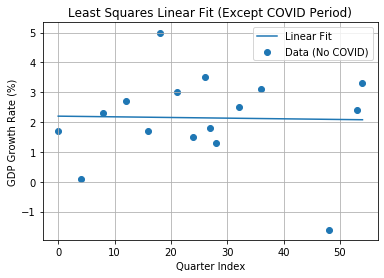

In [7]:
#Creates a boolean mask to exclude data points between index 14 and 17 (COVID-19 impact).
#This prevents the extreme fluctuations from skewing the linear trend.
mask = (x < 40) | (x > 44)
x_lin = x[mask]
y_lin = y[mask]


#Least Squares Calculation
#Instead of using a library, this calculates the slope (m) and intercept (b) 
#using the closed-form solutions derived from the Normal Equations.
n = len(x_lin)

m = (n*np.sum(x_lin*y_lin) - np.sum(x_lin)*np.sum(y_lin)) / \
    (n*np.sum(x_lin**2) - (np.sum(x_lin))**2)

b = (np.sum(y_lin) - m*np.sum(x_lin)) / n

print("Slope:", m)

#Plotting
plt.figure()
plt.scatter(x_lin, y_lin, label="Data (No COVID)")
plt.plot(x, m*x + b, label="Linear Fit")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Least Squares Linear Fit (Except COVID Period)")
plt.legend()
plt.grid()

plt.show()

Linear Fit RMSE (excluding COVID): 1.4430777454311892


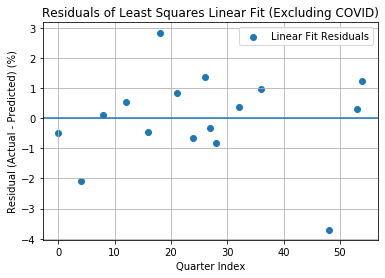

In [8]:
# Residual plot for the linear fit
y_lin_pred = m * x_lin + b
lin_residuals = y_lin - y_lin_pred

print("Linear Fit RMSE (excluding COVID):", rmse(y_lin, y_lin_pred))


#Plotting
plt.figure()
plt.scatter(x_lin, lin_residuals, label="Linear Fit Residuals")
plt.axhline(0)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residuals of Least Squares Linear Fit (Excluding COVID)")
plt.legend()
plt.grid()
plt.show()

**Discussion (B2):**

The slope of the linear fit is about -0.017% per quarter, which is basically zero. This tells us that when we exclude the COVID shock, GDP growth did not really have a strong upward or downward trend from 2010 to 2023 staying relatively stable. Whether a linear trend makes economic sense depends on the context. Over a period like 2010 to 2023, GDP growth does not typically follow a straight line. It is influenced by business cycles, policy decisions, and global events, so a linear model is a simplification. That being said, the result is still meaningful. A slope near zero suggests that there was no long-term acceleration or slowdown in growth outside of the COVID period.For a linear model to be appropriate, several assumptions must hold:For a linear model to be valid you would need to assume that the relationship between time and GDP growth is actually linear, that the errors are random and not correlated over time, and that the variability of growth does not change over time.
We excluded the COVID quarters (2020 Q1 through 2021 Q1, indices 14-17) because including them would completely dominate the fit the extreme values of -28.1% and +33.8% would drag the slope wildly and make the linear model meaningless for describing normal economic conditions.

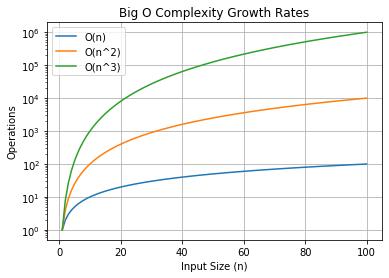

In [9]:
import matplotlib.pyplot as plt
import numpy as np

n = np.linspace(1, 100, 100)

plt.plot(n, n, label='O(n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')

plt.yscale('log')  # Log scale for better comparison
plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operations')
plt.legend()
plt.grid()

plt.show()


## Part C — Method Justification

**C1. Which Method to Recommend for Interpolation?**

The natural cubic spline serves as the best method to estimate GDP growth between two quarterly periods. The smoothness of cubic spline functions stands as their major beneficial feature. The function provides C2 continuity protection which ensures that all elements of the curve maintain continuous movement throughout its entire length. The model establishes effective GDP projections because actual economic development patterns display smooth transitions without abrupt boundaries during quarterly intervals. The polynomial model maintains continuous smoothness throughout its entire range, while the basic linear model creates a direct connection between data points which fails to reveal any intermediate patterns. The spline achieves precise interpolation results because it passes through each data point which results in an RMSE measurement of 0. The policymaker requires the curve to attach itself to actual observed values when he needs to predict numbers that exist between two confirmed quarter results. The degree-4 polynomial, by contrast, has an RMSE around 9.97%. The interpolation results will demonstrate significant errors because the data points do not intersect with the actual data. The exact RMSE value of the spline serves as its strongest point, which creates its most significant disadvantage. The system needs to reach all data points precisely which results in extreme distortion from the two extreme COVID-19 quarters which recorded -28.1% and +33.8% changes. The spline produces incorrect results whenever interpolation occurs during 2020 because the extreme outliers force the curve to follow their path. The polynomial model actually handles this specific issue a bit better since it just approximates the trend rather than forcing an exact fit.

Big O Notation: Big O notation is used to describe the upper bound of an algorithm's runtime as the input size n grows. It focuses on how fast the number of operations increases, ignoring constants and smaller terms. For this project all 3 methods have linear time complexity. The least squares linear fit is O(n) since it only requires one pass through the data to compute sums like x and xy. The polynomial fit using normal equations is also O(n) because the 4th degree is fixed, so building the system still scales linearly with n. Similarly cubic spline interpolation is O(n) because the tridiagonal system can be solved efficiently using the Thomas algorithm instead of a full O(n^3) solver.   

This doesn’t change the final recommendation. Since all methods scale linearly and the dataset is small (55 points), runtime isn’t really a concern. The choice depends more on the goal: cubic splines are better for exact interpolation between points, while polynomial fitting is better for capturing an overall trend and handling noise.

Final Recommendation:
My final recommendation depends on the timeline you're looking at. For quarters further away from the COVID shock, the natural cubic spline is definitely the way to go it’s perfectly accurate at the nodes and mathematically guaranteed to be C2 smooth.
But if you need to interpolate near or during the pandemic period, you'd probably want to switch to a smoothing spline (which relaxes the exact fit requirement) or use weighted least squares to down-weight those extreme COVID quarters. I wouldn't use the plain linear model at all, since it just can't capture the nonlinear swings in the macroeconomic data.
Just to recap the numbers: the spline gives you an RMSE of 0 compared to the polynomial's ~9.97%. Also, while the polynomial's condition number (around 480,000) is acceptable for a degree-4, its global smoothness can get unpredictable near outliers, and that condition number would blow up quickly if we tried using a higher-degree polynomial to force a better fit.

---
## Conclusion

Ultimately, the best method depends on your analytical goal. The natural cubic spline provide the best interpolation for stable period but can be susceptible for extreme outliers, such as COVID. In comparison, the degree 4 polynomal trades precision for stability, giving a general picture of the economic trend without distorting extreme cases. The linear model while ineffective for interpolation, confirms how long term GDP has remained flat for long periods of time. Real world datasets include expected outliers that emphasizes the importance of choosing models based on data and the intended applications.


## Citations

U.S. Bureau of Economic Analysis (BEA). Seasonally adjusted annual rate (SAAR) of real
GDP growth, in percent.

Utilized ChatGPT for plotting, report structure, comments, and help with verifying understanding for justification sections
Previous homeworks and challenges were also utilized from COE311k for this project 
